In [155]:
import numpy as np;
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn import metrics

In [156]:
df = pd.read_csv('data.csv')
df

,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.20
1,2000-01-04,1594.40,1641.95,1594.40,1638.70
2,2000-01-05,1634.55,1635.50,1555.05,1595.80
3,2000-01-06,1595.80,1639.00,1595.80,1617.60
4,2000-01-07,1616.60,1628.25,1597.20,1613.30
...,...,...,...,...,...
6310,2025-05-20,24996.20,25010.35,24669.70,24683.90
6311,2025-05-21,24744.25,24946.20,24685.35,24813.45
6312,2025-05-22,24733.95,24737.50,24462.40,24609.70
6313,2025-05-23,24639.50,24909.05,24614.05,24853.15


In [157]:
df['Date'] = pd.to_datetime(df['Date'])
df

,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.20
1,2000-01-04,1594.40,1641.95,1594.40,1638.70
2,2000-01-05,1634.55,1635.50,1555.05,1595.80
3,2000-01-06,1595.80,1639.00,1595.80,1617.60
4,2000-01-07,1616.60,1628.25,1597.20,1613.30
...,...,...,...,...,...
6310,2025-05-20,24996.20,25010.35,24669.70,24683.90
6311,2025-05-21,24744.25,24946.20,24685.35,24813.45
6312,2025-05-22,24733.95,24737.50,24462.40,24609.70
6313,2025-05-23,24639.50,24909.05,24614.05,24853.15


In [158]:
df = df.sort_values('Date')
df

,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.20
1,2000-01-04,1594.40,1641.95,1594.40,1638.70
2,2000-01-05,1634.55,1635.50,1555.05,1595.80
3,2000-01-06,1595.80,1639.00,1595.80,1617.60
4,2000-01-07,1616.60,1628.25,1597.20,1613.30
...,...,...,...,...,...
6310,2025-05-20,24996.20,25010.35,24669.70,24683.90
6311,2025-05-21,24744.25,24946.20,24685.35,24813.45
6312,2025-05-22,24733.95,24737.50,24462.40,24609.70
6313,2025-05-23,24639.50,24909.05,24614.05,24853.15


In [159]:
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


In [160]:
df['day_of_week'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month
df['daily_return'] = (df['Close'] - df['Open'])/df['Open']  #Daily Return - Daily Performamce
df['range'] = df['High'] - df['Low'] #Range - Intraday Volatility
df['range_pct'] = (df['High'] - df['Low']) / df['Open'] # Measure %Volatlility
df['co_diff'] = df['Close'] - df['Open'] #Know the difference between Close and Open
df['next_close'] = df['Close'].shift(-1); #Know next day's close
for i in range(1,5):
  df[f'Close_lag_{i}'] = df['Close'].shift(i)
df['rolling_mean_5'] = df['Close'].rolling(window=5).mean()
df['rolling_std_5'] = df['Close'].rolling(window=5).std()
df['rolling_mean_10'] = df['Close'].rolling(window=10).mean()
df['rolling_std_10'] = df['Close'].rolling(window=10).std()
new_df = df.dropna()
new_df

,Date,Open,High,Low,Close,day_of_week,Month,daily_return,range,range_pct,co_diff,next_close,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10
9,2000-01-14,1622.15,1627.40,1591.40,1622.70,4,1,0.000339,36.00,0.022193,0.55,1611.60,1621.40,1624.80,1572.50,1632.90,1614.86,24.097987,1613.190,20.412439
10,2000-01-17,1623.50,1668.45,1604.65,1611.60,0,1,-0.007330,63.80,0.039298,-11.90,1606.70,1622.70,1621.40,1624.80,1572.50,1610.60,21.893492,1615.130,19.073894
11,2000-01-18,1611.65,1615.15,1587.85,1606.70,1,1,-0.003071,27.30,0.016939,-4.95,1634.80,1611.60,1622.70,1621.40,1624.80,1617.44,7.857671,1611.930,17.280178
12,2000-01-19,1610.05,1644.45,1608.85,1634.80,2,1,0.015372,35.60,0.022111,24.75,1601.10,1606.70,1611.60,1622.70,1621.40,1619.44,10.887745,1615.830,17.632675
13,2000-01-20,1634.65,1644.40,1596.65,1601.10,3,1,-0.020524,47.75,0.029211,-33.55,1620.60,1634.80,1606.70,1611.60,1622.70,1615.38,13.456114,1614.180,18.211157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6309,2025-05-19,25005.35,25062.95,24916.65,24945.45,0,5,-0.002395,146.30,0.005851,-59.90,24683.90,25019.80,25062.10,24666.90,24578.35,24854.52,218.028859,24627.310,357.757549
6310,2025-05-20,24996.20,25010.35,24669.70,24683.90,1,5,-0.012494,340.65,0.013628,-312.30,24813.45,24945.45,25019.80,25062.10,24666.90,24875.63,187.589637,24657.740,347.130540
6311,2025-05-21,24744.25,24946.20,24685.35,24813.45,2,5,0.002797,260.85,0.010542,69.20,24609.70,24683.90,24945.45,25019.80,25062.10,24904.94,155.533153,24697.645,338.887669
6312,2025-05-22,24733.95,24737.50,24462.40,24609.70,3,5,-0.005023,275.10,0.011122,-124.25,24853.15,24813.45,24683.90,24945.45,25019.80,24814.46,171.971282,24731.235,307.392352


In [161]:
#Splitting the dataset
X = new_df.drop(['Date','next_close'],axis=1)
Y = new_df['next_close']

#Splitting into train and testing dataset
train_size = int(len(X)*0.8)
X_train = X.iloc[:train_size,:]
Y_train = Y.iloc[:train_size]
X_test = X.iloc[train_size:,:]
Y_test = Y.iloc[train_size:]
X

,Open,High,Low,Close,day_of_week,Month,daily_return,range,range_pct,co_diff,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,rolling_mean_5,rolling_std_5,rolling_mean_10,rolling_std_10
9,1622.15,1627.40,1591.40,1622.70,4,1,0.000339,36.00,0.022193,0.55,1621.40,1624.80,1572.50,1632.90,1614.86,24.097987,1613.190,20.412439
10,1623.50,1668.45,1604.65,1611.60,0,1,-0.007330,63.80,0.039298,-11.90,1622.70,1621.40,1624.80,1572.50,1610.60,21.893492,1615.130,19.073894
11,1611.65,1615.15,1587.85,1606.70,1,1,-0.003071,27.30,0.016939,-4.95,1611.60,1622.70,1621.40,1624.80,1617.44,7.857671,1611.930,17.280178
12,1610.05,1644.45,1608.85,1634.80,2,1,0.015372,35.60,0.022111,24.75,1606.70,1611.60,1622.70,1621.40,1619.44,10.887745,1615.830,17.632675
13,1634.65,1644.40,1596.65,1601.10,3,1,-0.020524,47.75,0.029211,-33.55,1634.80,1606.70,1611.60,1622.70,1615.38,13.456114,1614.180,18.211157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6309,25005.35,25062.95,24916.65,24945.45,0,5,-0.002395,146.30,0.005851,-59.90,25019.80,25062.10,24666.90,24578.35,24854.52,218.028859,24627.310,357.757549
6310,24996.20,25010.35,24669.70,24683.90,1,5,-0.012494,340.65,0.013628,-312.30,24945.45,25019.80,25062.10,24666.90,24875.63,187.589637,24657.740,347.130540
6311,24744.25,24946.20,24685.35,24813.45,2,5,0.002797,260.85,0.010542,69.20,24683.90,24945.45,25019.80,25062.10,24904.94,155.533153,24697.645,338.887669
6312,24733.95,24737.50,24462.40,24609.70,3,5,-0.005023,275.10,0.011122,-124.25,24813.45,24683.90,24945.45,25019.80,24814.46,171.971282,24731.235,307.392352


In [162]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Step 1: Build and Train the Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)

# Step 2: Make Predictions
Y_train_pred = linear_model.predict(X_train)
Y_test_pred = linear_model.predict(X_test)

# Step 3: Evaluate Performance
print("=== Linear Regression Results ===")
print("Train R² Score:", metrics.r2_score(Y_train, Y_train_pred))
print("Test R² Score:", metrics.r2_score(Y_test, Y_test_pred))
print("Train MAE:", metrics.mean_absolute_error(Y_train, Y_train_pred))
print("Test MAE:", metrics.mean_absolute_error(Y_test, Y_test_pred))
print("Train MSE:", metrics.mean_squared_error(Y_train, Y_train_pred))
print("Test MSE:", metrics.mean_squared_error(Y_test, Y_test_pred))
ls = [24956.65,25062.90,24704.10,24826.20,1,5,-0.005227,358.8,0.014376,-130.45,25001.15,24853.15,24609.70,24813.45,24820.8,139.95,24848.215,158.682322]
print(linear_model.predict(np.array(ls).reshape(1,-1)))

=== Linear Regression Results ===
Train R² Score: 0.999512122561141
Test R² Score: 0.9982122854182421
Train MAE: 45.38601921434326
Test MAE: 124.27696793202313
Train MSE: 5209.33181401616
Test MSE: 29584.862618333722
[24828.4382761]


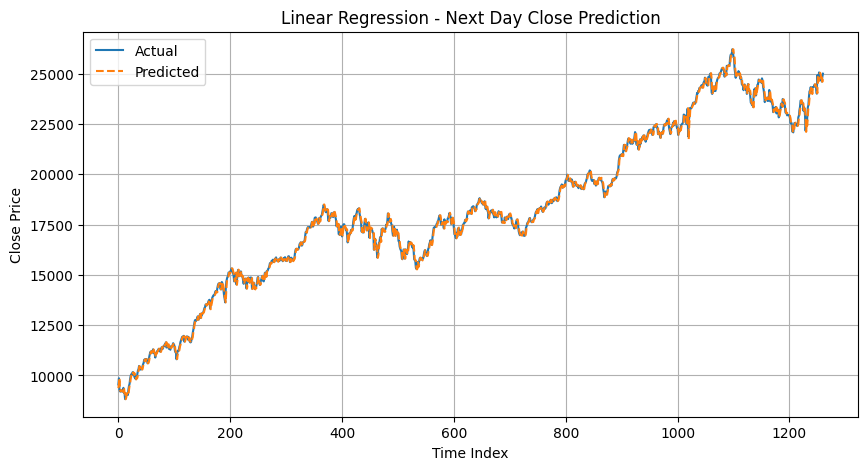

In [163]:
plt.figure(figsize=(10,5))
plt.plot(Y_test.values, label='Actual')
plt.plot(Y_test_pred, label='Predicted', linestyle='--')
plt.title("Linear Regression - Next Day Close Prediction")
plt.xlabel("Time Index")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()


[]

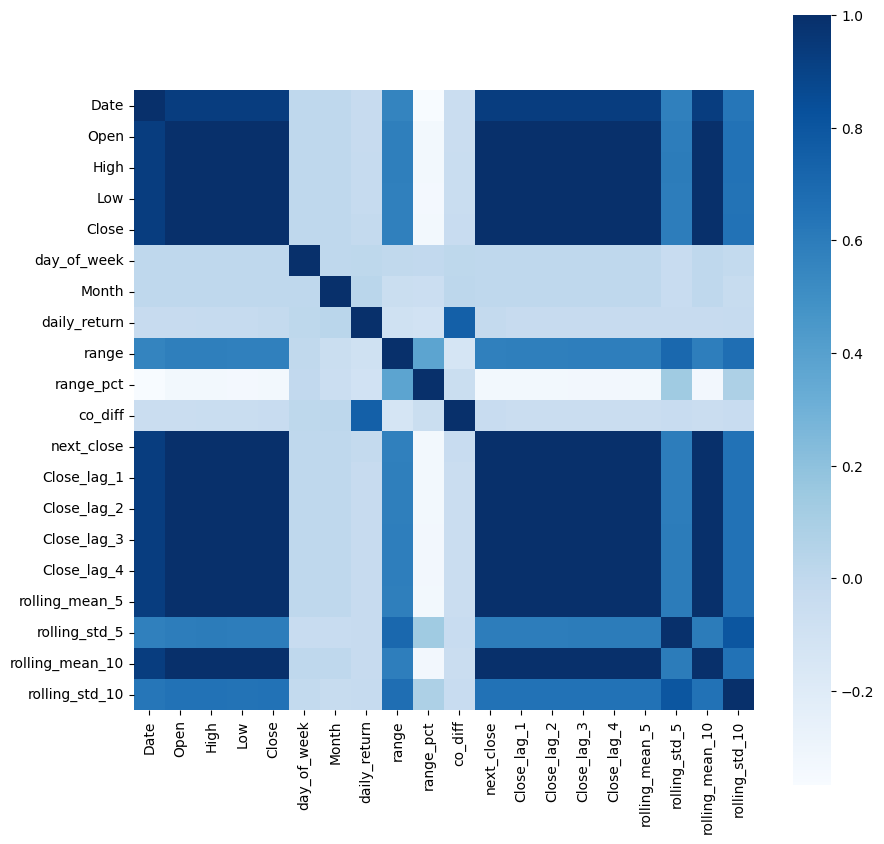

In [164]:
new_df_corr = new_df.corr()
plt.figure(figsize=(10,10))

sns.heatmap(new_df_corr,annot=False,cmap='Blues',square=True)
plt.plot()